In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score

In [10]:
# Organize the excel file in a dataframe
df = pd.read_excel("Concrete_Data.xls")

# Seperate the target variable (Concrete compressive strength) from the rest "predicting" attributes
X = df.drop(columns=['Concrete compressive strength(MPa, megapascals) '], axis=1)
# Target variable
y= df['Concrete compressive strength(MPa, megapascals) '].values

# Split data in training and test tests
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)

Fold 1: λ*=2.7826, h*=32, Ridge MSE=122.96, ANN MSE=58.16, Baseline MSE=333.29
Fold 2: λ*=0.3594, h*=32, Ridge MSE=94.44, ANN MSE=61.62, Baseline MSE=236.90
Fold 3: λ*=0.0464, h*=32, Ridge MSE=144.46, ANN MSE=72.08, Baseline MSE=343.29
Fold 4: λ*=0.3594, h*=32, Ridge MSE=90.76, ANN MSE=38.72, Baseline MSE=274.49
Fold 5: λ*=0.3594, h*=4, Ridge MSE=123.60, ANN MSE=109.61, Baseline MSE=261.27
Fold 6: λ*=0.3594, h*=1, Ridge MSE=139.59, ANN MSE=135.79, Baseline MSE=280.30
Fold 7: λ*=0.0001, h*=2, Ridge MSE=95.57, ANN MSE=85.80, Baseline MSE=279.38
Fold 8: λ*=0.3594, h*=16, Ridge MSE=123.18, ANN MSE=85.34, Baseline MSE=280.14
Fold 9: λ*=0.3594, h*=16, Ridge MSE=77.70, ANN MSE=50.34, Baseline MSE=272.62
Fold 10: λ*=0.3594, h*=32, Ridge MSE=122.72, ANN MSE=48.38, Baseline MSE=286.81


,Fold,λ*,h*,Ridge Test MSE,ANN Test MSE,Baseline MSE
0,1,2.782559,32,122.958991,58.156602,333.285016
1,2,0.359381,32,94.437316,61.624118,236.903196
2,3,0.046416,32,144.463996,72.078389,343.287175
3,4,0.359381,32,90.761377,38.715344,274.489578
4,5,0.359381,4,123.596327,109.607674,261.274561
5,6,0.359381,1,139.589362,135.791721,280.304005
6,7,0.000100,2,95.568788,85.799285,279.378598
7,8,0.359381,16,123.183715,85.339133,280.144982
8,9,0.359381,16,77.695829,50.344652,272.622592
9,10,0.359381,32,122.723856,48.378821,286.810173



Average Test MSEs (Outer CV):
Ridge Test MSE    113.497956
ANN Test MSE       74.583574
Baseline MSE      284.849988
dtype: float64


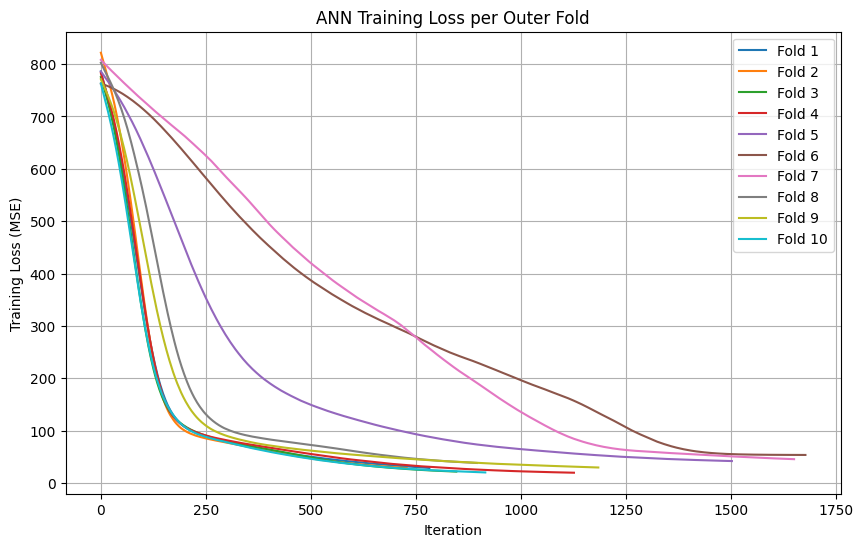


Final Evaluation on Held-out Test Set:
Ridge RMSE: 9.797
ANN RMSE:   6.619
Baseline:   16.054


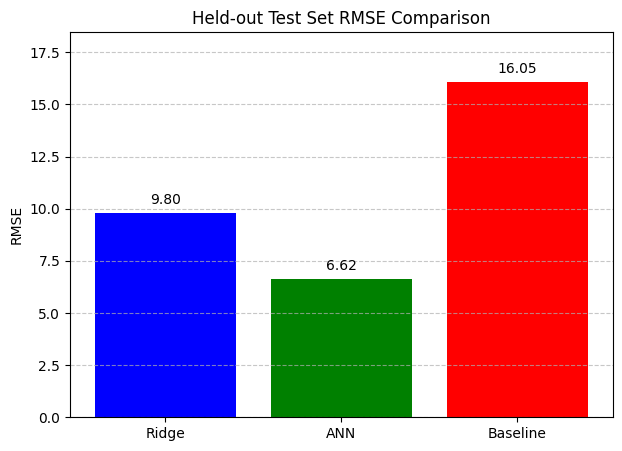

In [11]:
# Use only training data for model selection (outer CV)
X_scaled = X_train_std
y_scaled = y_train

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# --- Nested CV settings ---
K1 = K2 = 10
outer_cv = KFold(n_splits=K1, shuffle=True, random_state=42)
lambdas = np.logspace(-4, 4, 10)       # Ridge tuning
h_values = [1, 2, 4, 8, 16, 32]        # ANN tuning

# Store results and ANN training curves
results = []
ann_loss_curves = []

# Outer CV loop
fold_number = 1
X_scaled = X_train_std
y_scaled = y_train

for train_idx, test_idx in outer_cv.split(X_scaled):
    X_train_outer, X_test_outer = X_scaled[train_idx], X_scaled[test_idx]
    y_train_outer, y_test_outer = y_scaled[train_idx], y_scaled[test_idx]

    # Inner CV
    inner_cv = KFold(n_splits=K2, shuffle=True, random_state=fold_number)

    # --- Ridge inner loop ---
    ridge_scores = []
    for l in lambdas:
        inner_mse = []
        for itrain, ival in inner_cv.split(X_train_outer):
            ridge = Ridge(alpha=l)
            ridge.fit(X_train_outer[itrain], y_train_outer[itrain])
            y_val_pred = ridge.predict(X_train_outer[ival])
            inner_mse.append(mean_squared_error(y_train_outer[ival], y_val_pred))
        ridge_scores.append(np.mean(inner_mse))
    best_lambda = lambdas[np.argmin(ridge_scores)]

    # --- ANN inner loop ---
    ann_scores = []
    for h in h_values:
        inner_mse = []
        for itrain, ival in inner_cv.split(X_train_outer):
            ann = MLPRegressor(hidden_layer_sizes=(h,), max_iter=2000, random_state=fold_number,
                               early_stopping=True)
            ann.fit(X_train_outer[itrain], y_train_outer[itrain])
            y_val_pred = ann.predict(X_train_outer[ival])
            inner_mse.append(mean_squared_error(y_train_outer[ival], y_val_pred))
        ann_scores.append(np.mean(inner_mse))
    best_h = h_values[np.argmin(ann_scores)]

    # --- Evaluate models on outer test set ---
    # Ridge
    ridge_final = Ridge(alpha=best_lambda)
    ridge_final.fit(X_train_outer, y_train_outer)
    ridge_test_mse = mean_squared_error(y_test_outer, ridge_final.predict(X_test_outer))

    # ANN
    ann_final = MLPRegressor(hidden_layer_sizes=(best_h,), max_iter=2000, random_state=fold_number,
                             early_stopping=True)
    ann_final.fit(X_train_outer, y_train_outer)
    ann_test_mse = mean_squared_error(y_test_outer, ann_final.predict(X_test_outer))
    ann_loss_curves.append(ann_final.loss_curve_)

    # Baseline (mean of training target)
    baseline_pred = np.full_like(y_test_outer, y_train_outer.mean())
    baseline_mse = mean_squared_error(y_test_outer, baseline_pred)

    # Store results
    results.append({
        'Fold': fold_number,
        'λ*': best_lambda,
        'h*': best_h,
        'Ridge Test MSE': ridge_test_mse,
        'ANN Test MSE': ann_test_mse,
        'Baseline MSE': baseline_mse
    })

    print(f"Fold {fold_number}: λ*={best_lambda:.4f}, h*={best_h}, Ridge MSE={ridge_test_mse:.2f}, ANN MSE={ann_test_mse:.2f}, Baseline MSE={baseline_mse:.2f}")
    fold_number += 1

# --- Display Table 1 ---
results_df = pd.DataFrame(results)
display(results_df)

print("\nAverage Test MSEs (Outer CV):")
print(results_df[['Ridge Test MSE', 'ANN Test MSE', 'Baseline MSE']].mean())

# --- Plot ANN training loss curves ---
plt.figure(figsize=(10,6))
for i, loss_curve in enumerate(ann_loss_curves):
    plt.plot(loss_curve, label=f'Fold {i+1}')   # start fold number at 1
plt.xlabel('Iteration')
plt.ylabel('Training Loss (MSE)')
plt.title('ANN Training Loss per Outer Fold')
plt.legend()
plt.grid(True)
plt.show()

# --- Evaluate final models on untouched test set ---
best_lambda_global = results_df['λ*'].mode()[0]
best_h_global = results_df['h*'].mode()[0]

ridge_final_global = Ridge(alpha=best_lambda_global)
ridge_final_global.fit(X_train_std, y_train)
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, ridge_final_global.predict(X_test_std)))

ann_final_global = MLPRegressor(hidden_layer_sizes=(best_h_global,), max_iter=2000,
                                random_state=42, early_stopping=True)
ann_final_global.fit(X_train_std, y_train)
ann_test_rmse = np.sqrt(mean_squared_error(y_test, ann_final_global.predict(X_test_std)))

baseline_rmse = np.sqrt(mean_squared_error(y_test, np.full_like(y_test, y_train.mean())))

print(f"\nFinal Evaluation on Held-out Test Set:")
print(f"Ridge RMSE: {ridge_test_rmse:.3f}")
print(f"ANN RMSE:   {ann_test_rmse:.3f}")
print(f"Baseline:   {baseline_rmse:.3f}")

# --- Optional: bar plot of held-out test RMSE ---
models = ['Ridge', 'ANN', 'Baseline']
rmse_values = [ridge_test_rmse, ann_test_rmse, baseline_rmse]

plt.figure(figsize=(7,5))
bars = plt.bar(models, rmse_values, color=['blue','green','red'])
plt.ylabel('RMSE')
plt.title('Held-out Test Set RMSE Comparison')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, max(rmse_values)*1.15)  # padding for labels

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.3, f'{height:.2f}',
             ha='center', va='bottom')
plt.show()

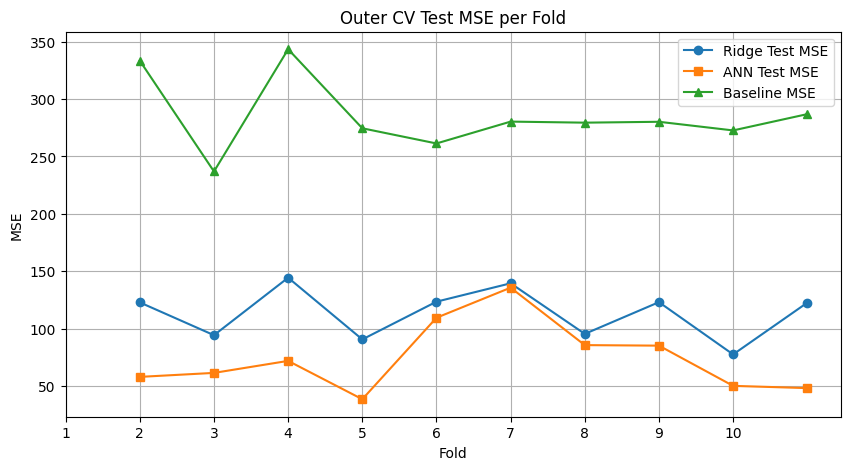

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Outer CV per fold
folds = results_df['Fold'].values
ridge_mse = [122.958991, 94.437316, 144.463996, 90.761377, 123.596327,
             139.589362, 95.568788, 123.183715, 77.695829, 122.723856]
ann_mse = results_df['ANN Test MSE'].values
baseline_mse = results_df['Baseline MSE'].values

plt.figure(figsize=(10,5))
plt.plot(folds+1, ridge_mse, marker='o', label='Ridge Test MSE')
plt.plot(folds+1, ann_mse, marker='s', label='ANN Test MSE')
plt.plot(folds+1, baseline_mse, marker='^', label='Baseline MSE')
plt.xlabel('Fold')
plt.ylabel('MSE')
plt.title('Outer CV Test MSE per Fold')
plt.xticks(folds)
plt.grid(True)
plt.legend()
plt.show()
